In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

#mypass = '/mnt/e/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

output = 'global_order_boxplot.pdf'

input_dir = Path(mypass)

experiments = [
    "20260121/beads_trans_crop_crop",
    "20260121/exp_crop1",
    "20260122/exp",
    "20260122/exp001",
    "beads3um/20260416"
]

op_data = []
labels = ["exp1","exp2", "exp3", "exp4", "exp1"]

i = 0

# データの読み込み
for exp_subpath in experiments:
    target_path = input_dir / exp_subpath / "MTs_order_parameter.zarr"
    
    if target_path.exists():
        try:
            op_zarr = zarr.open(str(target_path), mode='r')
            op = op_zarr[:]
            
            # NaNなどの無効な値を除外して1次元配列にする
            op = np.array(op).flatten()
            op = op[~np.isnan(op)]
            op_data.append(op)
            
            # ラベルに実験のサブパスを使用
            #labels.append(f'exp{i}')
            
            num = len(op)
            op_mean = np.mean(op) if num > 0 else np.nan
            op_sem = np.std(op, ddof=1)/np.sqrt(num) if num > 1 else 0
            print(f"exp{i}: Mean = {op_mean:.4f}, SEM = {op_sem:.4f}, N = {num}")

            i+=1
            
        except Exception as e:
            print(f"Error loading {target_path}: {e}")
    else:
        print(f"Warning: {target_path} does not exist.")

exp0: Mean = 0.9753, SEM = 0.0007, N = 271
exp1: Mean = 0.9911, SEM = 0.0000, N = 491
exp2: Mean = 0.9719, SEM = 0.0010, N = 271
exp3: Mean = 0.9824, SEM = 0.0002, N = 501
exp4: Mean = 0.9504, SEM = 0.0010, N = 88


Saved boxplot to global_order_boxplot.pdf


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_74275/137610482.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True)


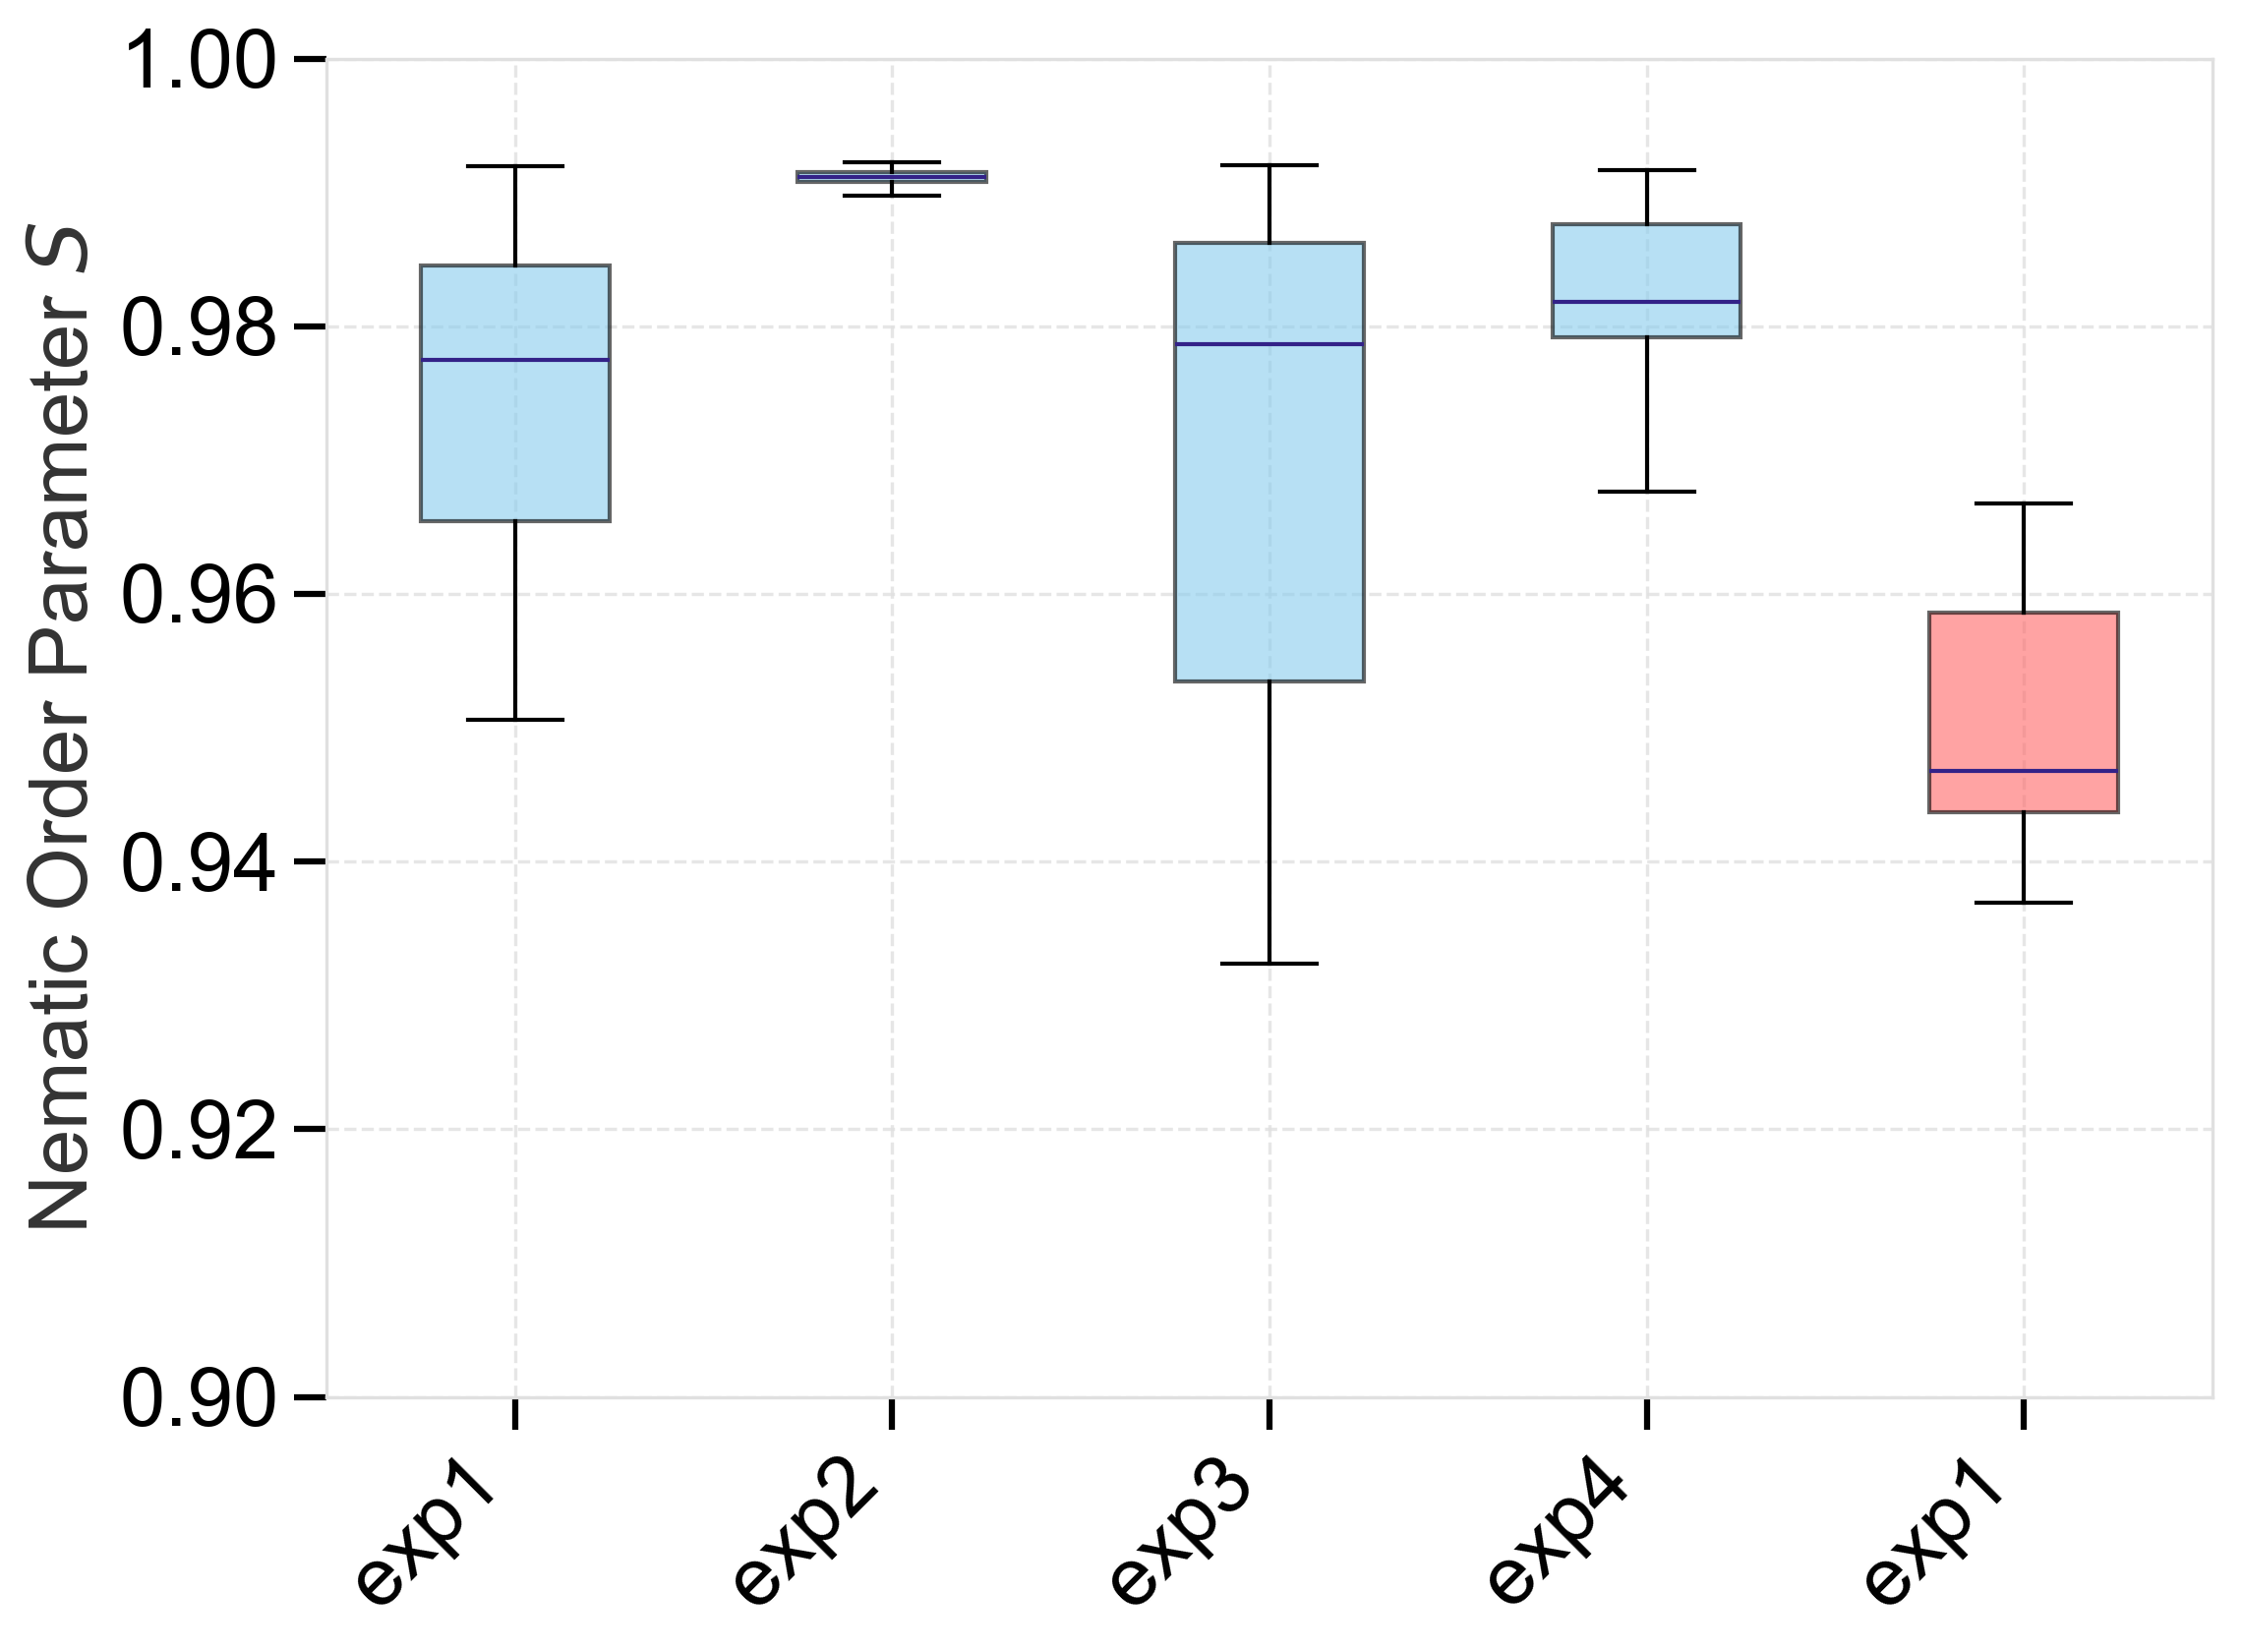

In [7]:
# 箱ひげ図の作成
if op_data:
    fig, ax = plt.subplots()
    
    # ボックスプロットを描画
    bp = ax.boxplot(op_data, labels=labels, patch_artist=True)
    
    # 見やすくするために色を付ける（オプション）
    for box in bp['boxes']:
        box.set(facecolor='#88CCEE', alpha=0.6)

    bp['boxes'][4].set(facecolor='#FF6666', alpha=0.6)

    ax.set_ylabel("Nematic Order Parameter $S$")
    #ax.set_title("Order Parameter per Experiment")
    ax.set_ylim(0.9, 1.0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # 画像の保存
    plt.savefig(input_dir/output, dpi=300)
    print(f"Saved boxplot to {output}")
else:
    print("No valid data available to plot.")

In [ ]:
def load_op_data(exp_subpath):
    target_path = input_dir / exp_subpath / "MTs_order_parameter.zarr"
    if target_path.exists():
        try:
            op_zarr = zarr.open(str(target_path), mode='r')
            op = op_zarr[:]
            
            # NaNなどの無効な値を除外して1次元配列にする
            op = np.array(op).flatten()
            op = op[~np.isnan(op)]
            
            num = len(op)
            op_mean = np.mean(op) if num > 0 else np.nan
            op_sem = np.std(op, ddof=1)/np.sqrt(num) if num > 1 else 0
            print(f"Mean = {op_mean:.4f}, SEM = {op_sem:.4f}, N = {num}")
            
        except Exception as e:
            print(f"Error loading {target_path}: {e}")

    return op

op_datas = []
labels = []

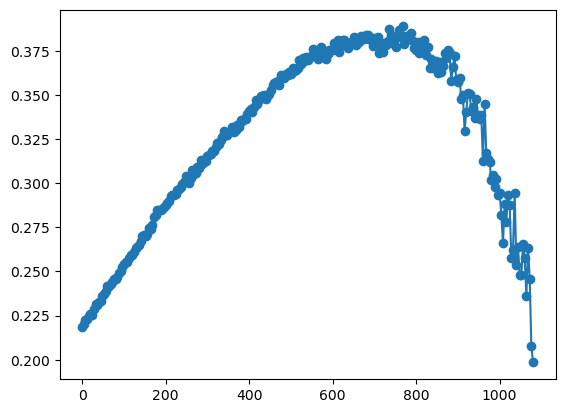

In [ ]:
import zarr
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

def load_op(path, interval = 4):
    theta_zarr = zarr.open(path, mode = 'r')
    theta = theta_zarr[:]
    x = np.cos(theta)
    y = np.sin(theta)
    theta_mean = np.arctan2(np.nanmean(y, axis = (1,2)), np.nanmean(x, axis=(1,2)))

    return np.arange(theta_mean.shape[0])*interval, theta_mean

t, theta = load_op('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/MTs_im_theta.zarr')
plt.plot(t, theta, marker = 'o')

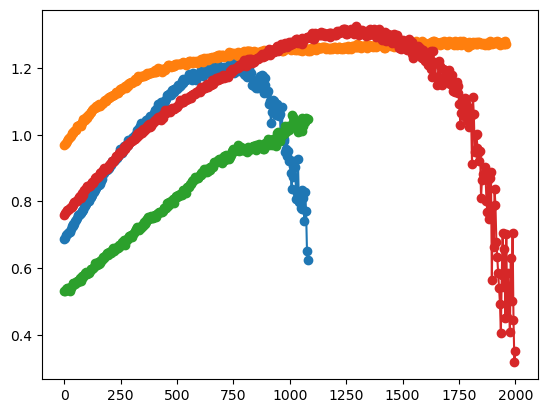

In [17]:
t1, theta1 = load_op('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/MTs_im_theta.zarr')
t2, theta2 = load_op('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/MTs_im_theta.zarr')
t3, theta3 = load_op('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/MTs_im_theta.zarr')
t4, theta4 = load_op('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001/MTs_im_theta.zarr')
plt.plot(t1, theta1, marker = 'o')
plt.plot(t2, theta2, marker = 'o')
plt.plot(t3, theta3, marker = 'o')
plt.plot(t4, theta4, marker = 'o')

Fitted parameters: A = 0.0010, B = 0.7009
Fitted parameters: A = 0.0005, B = 0.9951
Fitted parameters: A = 0.0006, B = 0.5285
Fitted parameters: A = 0.0007, B = 0.7674


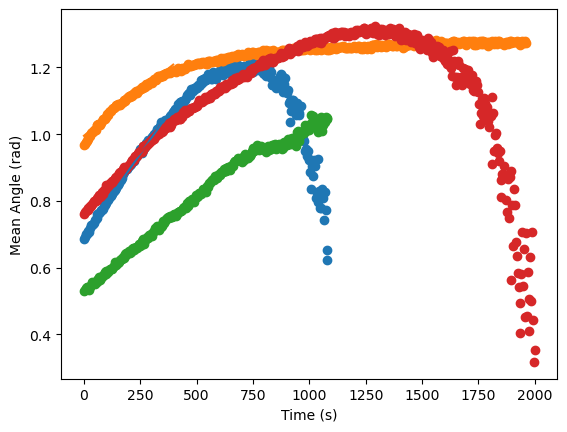

In [29]:
def fit(t, theta, t_min=0, t_max=100):
    popt, pcov = curve_fit(lambda t, A, B: A*t+B, t[t_min:t_max], theta[t_min:t_max])

    plt.scatter(t, theta)
    plt.plot(t[t_min:t_max], popt[0]*t[t_min:t_max] + popt[1], label=f'Fit: A={popt[0]:.2f}, B={popt[1]:.2f}')

    plt.xlabel('Time (s)')
    plt.ylabel('Mean Angle (rad)')

    print(f"Fitted parameters: A = {popt[0]:.4f}, B = {popt[1]:.4f}")

    return popt, pcov

popt1, pcov1 = fit(t1, theta1)
popt2, pcov2 = fit(t2, theta2)
popt3, pcov3 = fit(t3, theta3)
popt4, pcov4 = fit(t4, theta4)